In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\Project\fake_personal_finance_1000.csv")

df['Date'] = pd.to_datetime(df['Date'])
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df.drop_duplicates(inplace=True)
df['Category'] = df['Category'].fillna('Other')

print(df.head())

        Date       Category    Description  Amount
0 2026-02-21      Education  Online Course   65.52
1 2026-01-15      Utilities    Electricity  186.62
2 2026-03-13  Entertainment          Movie   77.86
3 2026-03-02      Utilities          Water  170.74
4 2026-01-21      Utilities       Internet   52.70


In [2]:
# Extract month from date
df['Month'] = df['Date'].dt.to_period('M')

# Pivot table: Category vs Month
monthly_spending = df.pivot_table(
    index='Category', 
    columns='Month', 
    values='Amount', 
    aggfunc='sum'
)

print(monthly_spending)

Month          2026-01  2026-02  2026-03
Category                                
Clothing       3743.22  3372.10  2608.81
Dining Out     1441.28  1080.07  1439.10
Education      4269.28  2752.75  3949.91
Entertainment  1969.16  1566.79  1957.50
Groceries      3334.62  3194.30  2063.37
Healthcare     2998.80  2816.66  2751.76
Misc           1818.23  1540.67  1446.19
Subscriptions   414.36   462.05   402.88
Transport       990.03   759.88  1146.79
Utilities      5032.24  3231.60  4807.70


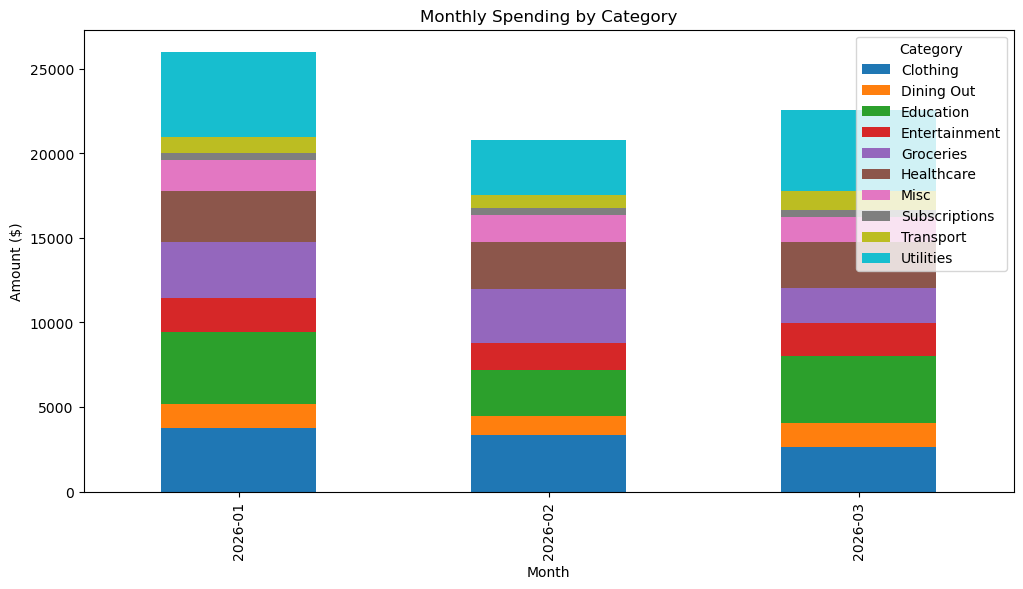

In [3]:
import matplotlib.pyplot as plt

monthly_spending.T.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Monthly Spending by Category')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.legend(title='Category')
plt.show()

In [6]:
print(df.dtypes)

Date           datetime64[ns]
Category               object
Description            object
Amount                float64
Month               period[M]
dtype: object


In [7]:
df['Month'] = df['Date'].dt.to_period('M')

In [8]:
df['Month'] = df['Date'].dt.strftime('%Y-%m')

In [9]:
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df = df.dropna(subset=['Amount'])

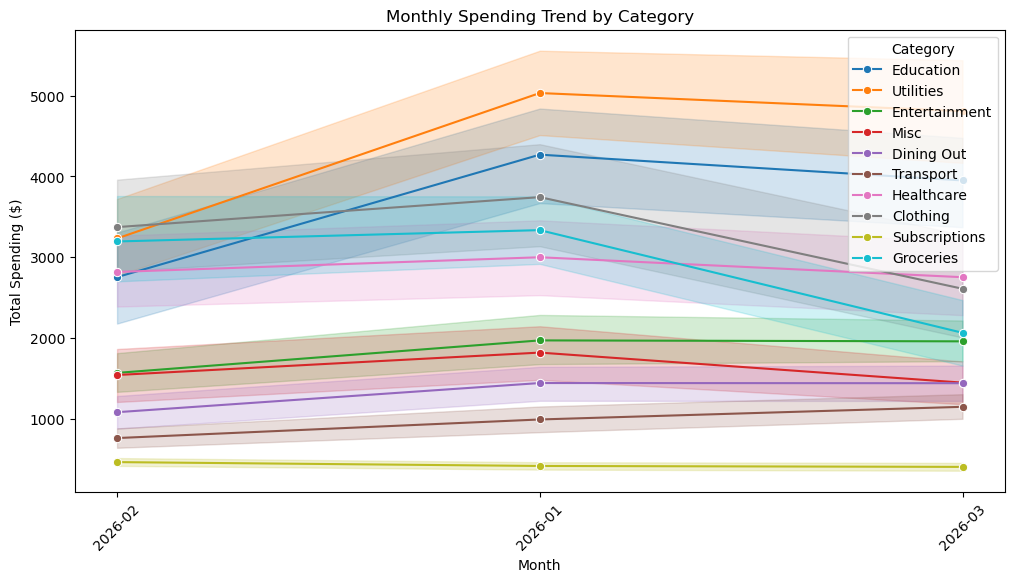

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='Month',
    y='Amount',
    hue='Category',
    estimator='sum',
    marker='o'
)

plt.title("Monthly Spending Trend by Category")
plt.xlabel("Month")
plt.ylabel("Total Spending ($)")
plt.xticks(rotation=45)

plt.show()

<Axes: xlabel='Month', ylabel='Amount'>

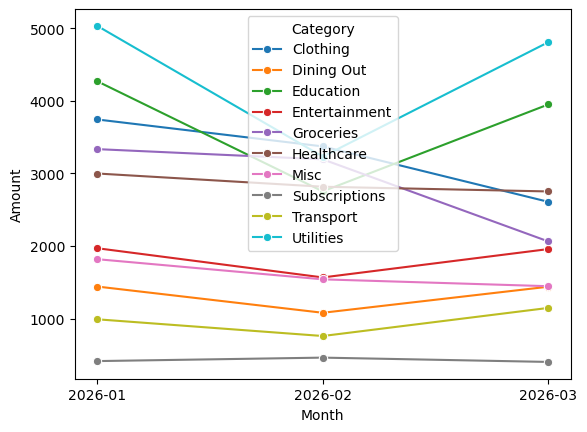

In [11]:
monthly_data = df.groupby(['Month','Category'])['Amount'].sum().reset_index()

sns.lineplot(
    data=monthly_data,
    x='Month',
    y='Amount',
    hue='Category',
    marker='o'
)

<Axes: xlabel='Month'>

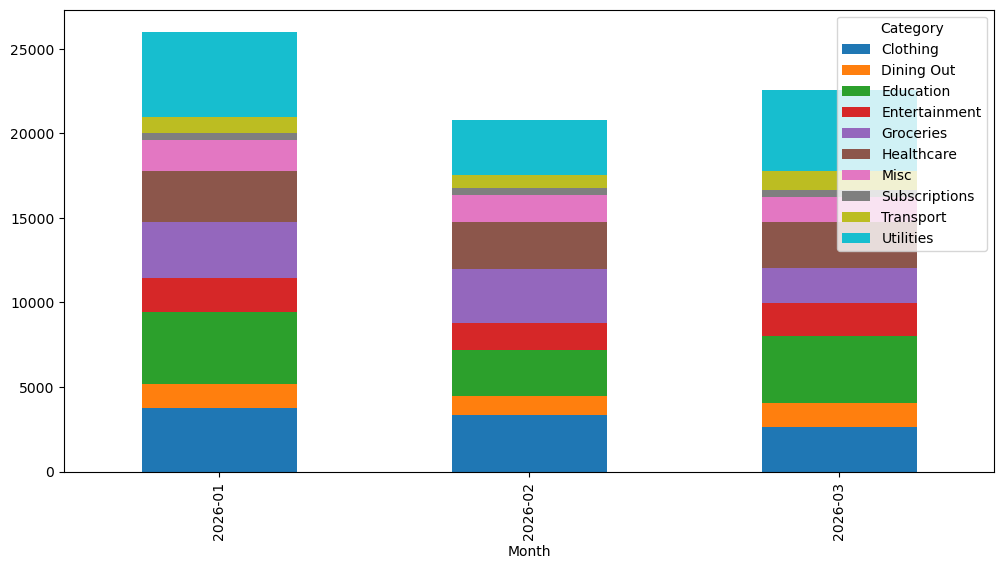

In [12]:
pivot = df.pivot_table(
    index='Month',
    columns='Category',
    values='Amount',
    aggfunc='sum'
)

pivot.plot(kind='bar', stacked=True, figsize=(12,6))

In [13]:
avg_per_category = df.groupby('Category')['Amount'].mean()
high_spending = avg_per_category[avg_per_category > 100]
print("Categories to review for savings:", high_spending)

Categories to review for savings: Category
Clothing     100.248763
Education    108.633069
Utilities    126.908155
Name: Amount, dtype: float64


<Axes: xlabel='Month'>

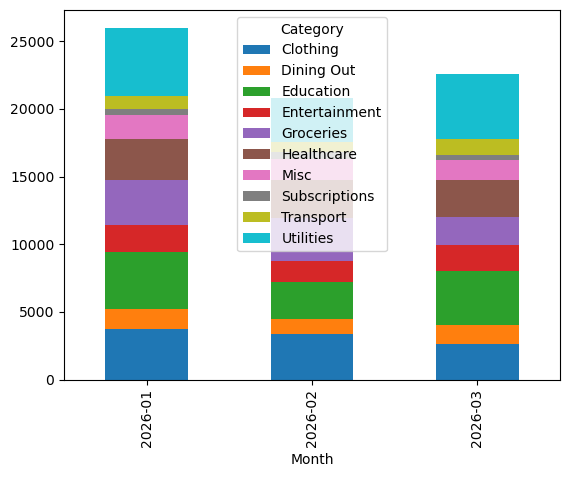

In [14]:
pivot.plot(kind='bar', stacked=True)

<Axes: xlabel='Month', ylabel='Amount'>

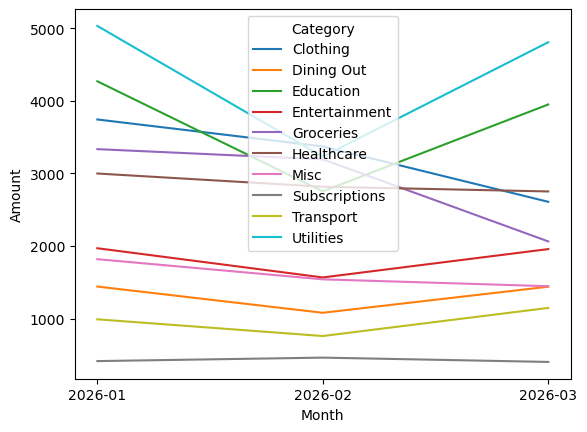

In [15]:
sns.lineplot(data=monthly_data, x='Month', y='Amount', hue='Category')